In [28]:
import numpy as np
import matplotlib.pyplot as plt
import math 
import random

#### constants

In [29]:
c = 299792458.0  #[m/s], speed of light
h = 6.62607015 * 10**(-34) #[Js], planck constant 
hbar = h / (2 * np.pi) #[Js], reduced planck consant
meKg = 9.1093837015 * 10**(-31) #[kg], electron mass
meKeV = 511 #[keV]electron mass in kev
g = 1/np.pi #coverage function, uniform on [0, pi]
t = np.linspace(0, np.pi, 1000) #possible scattering angles
na= 6.023e+23 #[atoms/mole], Avogadro number

#### simulation

In [30]:
class simulation:
    def __init__(self, isotope, energyPeak, halfLife, mass, molarMass, horizontal, depth, soilDensity, soilMAC, detRadius, detectionTime, mu):
        #parameters of the simulation
        self.isotope = isotope #type of isotope
        self.energyPeak = energyPeak #energy of the initial gamma photons
        self.halfLife = halfLife #half life in years
        self.mass = mass #radioactive source mass
        self.molarMass = molarMass #isotope molar mass
        self.horizontal = horizontal #horizontal distance source-detector
        self.depth = depth #source depth in the soil
        self.soilDensity = soilDensity #density of the soil
        self.soilMAC = soilMAC #soil mass absorption coefficient
        self.detRadius = detRadius #side length of the detector
        self.detectionTime = detectionTime #time of acquisition
        self.mu = mu #mean value of the rv (exponential) describing the number of scattering event  
   
    def radioSource(self):
        halfLifeS = self.halfLife*365.24*23.93*3600 #half lie expressed in seconds
        decayConstant = np.log(2)/halfLifeS 
        nAtoms = (self.mass*na)/self.molarMass
        A = decayConstant * nAtoms
        activity = round(A, 2) #[Bq], activity of the source 
        return activity
    
    def environment(self):
        soilAbs = self.soilDensity * self.soilMAC #soil absorption coefficient
        detCrossSection = self.detRadius**2 #[m^2] active detector area for photons collection
        distance = (self.horizontal**2 + self.depth**2)**0.5 #[m] average source-detector distance
        gammaIntensity = (detCrossSection*np.exp(-(distance*soilAbs))*self.radioSource())/(4*np.pi*distance**2)#n of photons reaching the detector
        gammaInteracting = round(gammaIntensity*self.detectionTime)
        return [gammaInteracting, distance]
    
    #toymodel: photoelectric vs compton cross section as a function of photon energy
    def crossSectionRatio(self, energy): 
        return .25*np.exp(-(1/300)*energy) 

    def firstInteraction(self): #function describing the first interaction the photons
        gammaPh = round(self.environment()[0]*self.crossSectionRatio(self.energyPeak)) #662 keV gamma undergoing photoelectric effect
        gammaCompton = round(self.environment()[0]-gammaPh) #662 keV gamma undergoing compton effect
        return [gammaPh, gammaCompton]
  
    def omegaFunction(self): #angular frequency of the scattered photon
        E = self.energyPeak*1000*1.602176634*10**(-19) #[J], initial photons energy in joule
        omega = E / hbar #[1/s], angular frequency
        return omega

    def R(self): #constant R, function of the angular frequency
        return hbar * self.omegaFunction()/(meKg * c**2) #constant R
        
    def I(self, angle): #function I(theta)
        return -np.cos(angle) / self.R()**2 + \
               np.log(1 + self.R() * (1 - np.cos(angle))) * (1/self.R() - 2/self.R()**2 - 2/self.R()**3) - \
               1 / (2 * self.R() * (1 + self.R() * (1 - np.cos(angle)))**2) + \
               1 / (1 + self.R() * (1 - np.cos(angle))) * (-2/self.R()**2 - 1/self.R()**3)

    def knpdf(self, angles): #the klein-nishina pdf
        omegaPrime = self.omegaFunction()/(1+(hbar*self.omegaFunction()/(meKg*c**2))*(1-np.cos(angles)))
        return (1/(self.I(np.pi)-self.I(0))) * (omegaPrime/self.omegaFunction())**2 * (self.omegaFunction()/omegaPrime + \
                omegaPrime/self.omegaFunction() -(np.sin(angles)**2))*np.sin(angles)

    #acceptance-rejection method to sample scattering angles from the klein-nishina pdf:
    def rejectionSampling(self): 
        samples = []
        sample = 0
        M = np.max(self.knpdf(t))/g 
        while True:
            x = np.random.uniform(0, np.pi)  #uniform sampling [0, pi]
            u = np.random.uniform(0, 1)  #uniform sampling [0, 1]
            if u <= self.knpdf(x) / (M * g): #acceptance-rejection algorithm
                sample = x
                break
        return sample

    def knSamplingPlot(self): #plot of the klein-nishina pdf alongside the simulated data
        thetaSamples = []
        for _ in range(self.firstInteraction()[1]):
            thetaSample = self.rejectionSampling()
            thetaSamples.append(thetaSample)
        knpdf = self.knpdf(t) #knpdf computed in the interval [0, pi]
        fig = plt.figure(facecolor=(1,1,1)) 
        plt.hist(thetaSamples, bins=1000, density=True, label='θ sampling', histtype='stepfilled', color='#007be8')
        plt.plot(t, knpdf, label='klein-nishina PDF', color='red', linewidth=2)
        plt.legend()
        plt.xlabel('θ')
        plt.title('compton scattering angles')
        fig.set_figheight(2.5)
        fig.set_figwidth(5)
        plt.grid(linewidth=0.3)
        plt.show()
        plt.close(fig)

    def energyLoss(self, gammaEnergy): #energy lost by a photon in a single scattering event
        return gammaEnergy*(1-(1/(1 + ((gammaEnergy/meKeV) * (1 - np.cos(self.rejectionSampling()))))))

    def resolution(self, energy):
        detResolution = 1.714824*energy**(-0.504)
        FWHM = energy * detResolution 
        sigma = FWHM / 2.335
        return sigma
        
    def compton(self):
        scatteringEventsNumber = np.random.exponential(self.mu, self.firstInteraction()[1]).astype(int)+2 #probability of the number of scattering events
        scatteringSteps = []
        deposited = []
        phAfterCompton = 0
        for i in scatteringEventsNumber:
            energyDep = np.zeros(i)
            energyRem = np.zeros(i)
            energyRem[0] = self.energyPeak
            for j in range(i-1):
                if self.crossSectionRatio(energyRem[j+1]) < np.random.uniform(0, 1):
                    energyDep[j] = self.energyLoss(energyRem[j])
                    energyRem[j+1] = energyRem[j] - energyDep[j]
                else:
                    phAfterCompton += 1
                    break                    
            scatteringSteps.append(energyDep)  
        for i in scatteringSteps:
            deposited.append(np.sum(i))
            depositedEnergies = np.array(deposited).astype(int) 
            depositedEnergies = depositedEnergies[depositedEnergies != 0]
        #each final energy deposited is measured with an uncertainty depending on the energy itself:
        for i in depositedEnergies:
            i = np.random.normal(i, self.resolution(i), 1)
        return [depositedEnergies, phAfterCompton]
    
    def photoelectric(self):
        comptonData = self.compton()[1]
        phCounts = np.random.normal(self.energyPeak, self.resolution(self.energyPeak), self.firstInteraction()[1]+comptonData).astype(int)
        return phCounts
    
    def gammaSpectrum(self):
        gammaSpec = np.concatenate((self.photoelectric(), self.compton()[0]), axis=None)
        energies, counts = np.unique(gammaSpec, return_counts=True)
        fig = plt.figure(facecolor=(1,1,1)) #axis color
        fig.set_figheight(2.5)
        fig.set_figwidth(5)
        plt.plot(energies, counts, color='#007be8', linewidth=1.5)
        plt.xlabel('energy [keV]')
        plt.ylabel('counts')
        plt.title(r'cs137 $\gamma$ spectrum')
        ax = plt.gca()
        ax.set_yscale('log')
        ax.grid(linewidth=0.3)
        plt.show()
        
    def comptonPlot(self):
        data = simulation.compton()[0]
        fig, ax = plt.subplots(figsize=(4, 2), facecolor=(1,1,1))
        plt.hist(data, bins=10000, label='θ sampling', color='#31A772', histtype='stepfilled', edgecolor='#31A772')
        ax.set_xlabel('energy')
        ax.set_ylabel('counts')
        ax.set_title('compton: energy deposited')
        ax.grid(linewidth=0.3)
        plt.show()

    def recap(self):
        comptonEdge = self.energyPeak*(1-(1/(1 + ((self.energyPeak/meKeV) * (1 - np.cos(np.pi))))))
        comptonEdge = round(comptonEdge, 2)
        print("isotope:", self.isotope)
        print("energy peak:", self.energyPeak, "keV")
        print("compton edge:", comptonEdge, "keV")
        print("isotope mass:", self.mass, "kg")
        print("source-detector distance:", self.environment()[1], "m")
        print("source activity:", self.radioSource(), "Bq")
        print("photons that initially undergo compton scattering:", self.firstInteraction()[1])
        print("photons absorbed immediatly by photoelectric effect:", self.firstInteraction()[0])
        print("photons absorbed by photoelectric effect after one or more Compton:", self.compton()[1])

#### running the simulation

In [31]:
sim = simulation('cs137', #isotope
                 661.7, #[keV] cs137 energy peak
                 30, #[years] half-life
                 1.5e-9, #[g] mass
                 136.907, #[g/mole], cs137 molar mass
                 0, #[m], source-detector horizontal distance
                 0.1, #[m], source depth in the soil
                 1.3, #[g/cm^3], soil density
                 0.08045, #[cm^2/g], soil mass attenuation coefficient
                 0.102, #[m], detector side length
                 120, #[s], 2 minutes - detection time
                 3) #mean value of the exponential pdf of the number of compton events

#### $\theta$ sampling plot

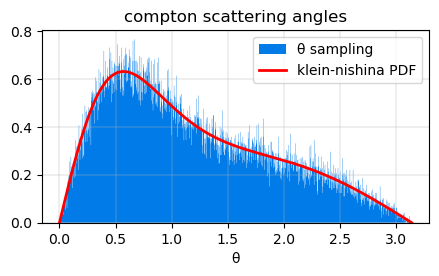

In [32]:
sim.knSamplingPlot()

#### full gamma spectrum

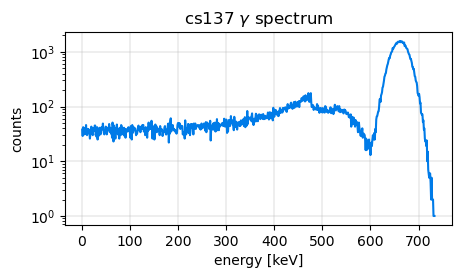

In [33]:
sim.gammaSpectrum()

In [35]:
sim.recap()

isotope: cs137
energy peak: 661.7 keV
compton edge: 477.37 keV
isotope mass: 1.5e-09 kg
source-detector distance: 0.1 m
source activity: 4845.73 Bq
photons that initially undergo compton scattering: 46330
photons absorbed immediatly by photoelectric effect: 1312
photons absorbed by photoelectric effect after one or more Compton: 25149
